In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
data = pd.read_excel('C:/Users/JOHN/Desktop/practice_data.xlsx')

In [104]:
data

,EmployeeID,gender,department,Days Present,Accuracy of Work,Meeting Project Deadlines,Task Completion Rates,Interpersonal Skills Rating,Decision-Making Skills Rating,Sales Revenue Generated,churned
0,1,Male,Sales,20,High,Yes,85,8,7,51638,No
1,2,Female,Marketing,22,Medium,Yes,90,7,6,97797,Yes
2,3,Male,Human Resources,25,High,No,80,9,8,95341,No
3,4,Male,Engineering,19,Low,Yes,75,6,5,91806,No
4,5,Female,Finance,23,Medium,Yes,85,7,7,64247,Yes
5,6,Male,Sales,21,High,Yes,95,8,8,89988,No
6,7,Female,Marketing,24,Low,No,70,5,4,70934,Yes
7,8,Male,Human Resources,18,Medium,Yes,80,6,6,96578,No
8,9,Male,Engineering,20,High,Yes,90,8,7,74219,No
9,10,Female,Finance,22,Medium,Yes,85,7,6,87009,Yes


# 35.Boxcox Transformation

In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox, shapiro

def boxcox_transformation(data, column_name):

    if any(data[column_name] <= 0):
        raise ValueError(f"All values in {column_name} must be positive for Box-Cox transformation.")
    
    # Apply Box-Cox
    transformed_data, _ = boxcox(data[column_name])
    data[f'{column_name}_boxcox'] = transformed_data

    # Shapiro-Wilk Test for normality
    stat, p_value = shapiro(data[f'{column_name}_boxcox'])

    # KDE Plot
    sns.kdeplot(data[f'{column_name}_boxcox'], fill=True)
    plt.title(f"KDE of {column_name} (Box-Cox Transformed)")
    plt.xlabel(f"{column_name}_boxcox")
    plt.show()

    # Output results
    print('Shapiro-Wilk Test P-value:', p_value)

    return data


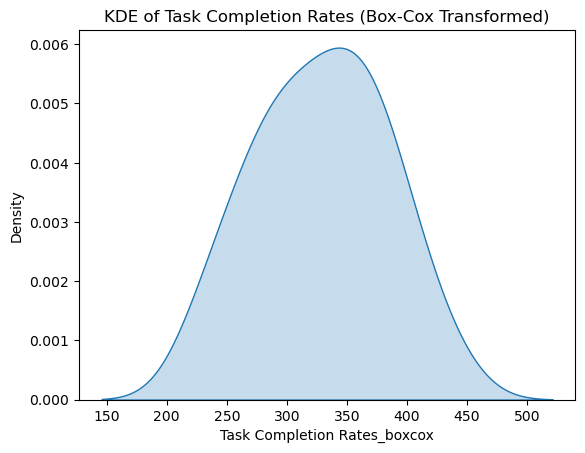

Shapiro-Wilk Test P-value: 0.3471811881204503


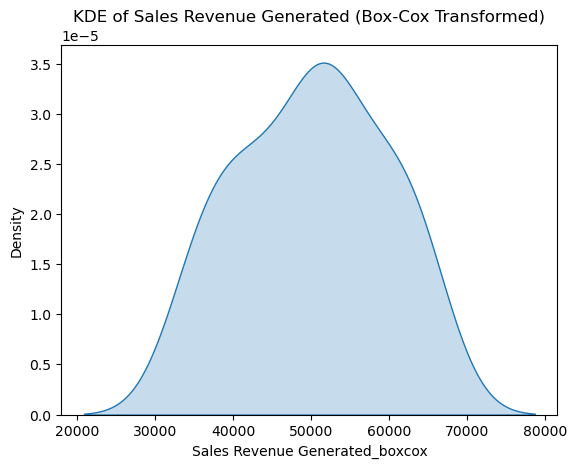

Shapiro-Wilk Test P-value: 0.11875345296433232


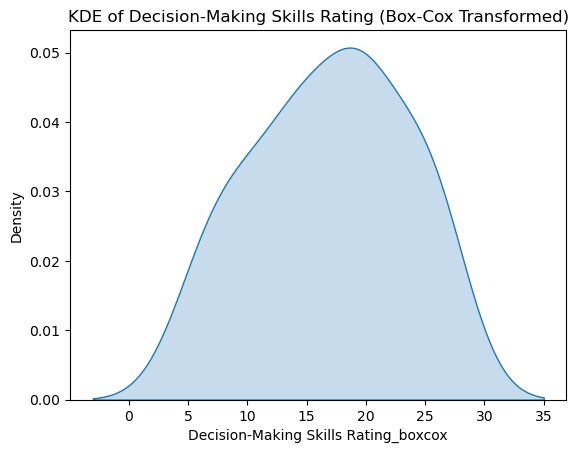

Shapiro-Wilk Test P-value: 0.006409900021360031


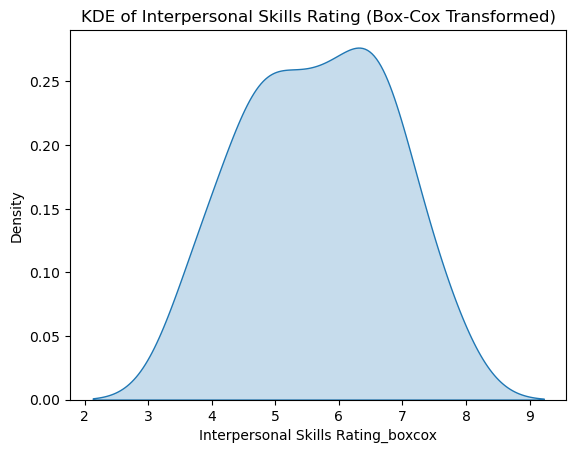

Shapiro-Wilk Test P-value: 0.01479109021190647


In [31]:
# Simple Data
data = boxcox_transformation(data, 'Task Completion Rates')
data = boxcox_transformation(data, 'Sales Revenue Generated')
data = boxcox_transformation(data, 'Decision-Making Skills Rating')
data = boxcox_transformation(data, 'Interpersonal Skills Rating')

# 36.Yeojohnson Transformation

In [110]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import yeojohnson, shapiro

def yeojohnson_transformation(data, column_name):
    # Yeo-Johnson Transformation
    transformed_data, _ = yeojohnson(data[column_name])
    data[f'{column_name}_yeojohnson'] = transformed_data

    # Shapiro-Wilk Test for normality
    stat, p_value = shapiro(data[f'{column_name}_yeojohnson'])

    # KDE Plot
    sns.kdeplot(data[f'{column_name}_yeojohnson'], fill=True)
    plt.title(f"KDE of {column_name} (Yeo-Johnson Transformed)")
    plt.xlabel(f"{column_name}_yeojohnson")
    plt.show()

    # Output
    print('Shapiro-Wilk Test P-value:', p_value)

    return data


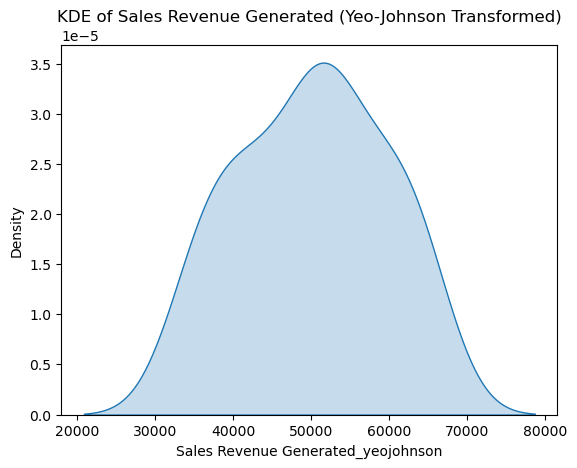

Shapiro-Wilk Test P-value: 0.1187535189210972


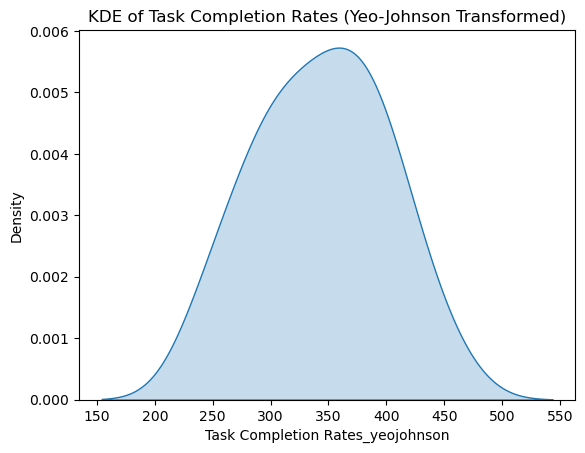

Shapiro-Wilk Test P-value: 0.3473060133855176


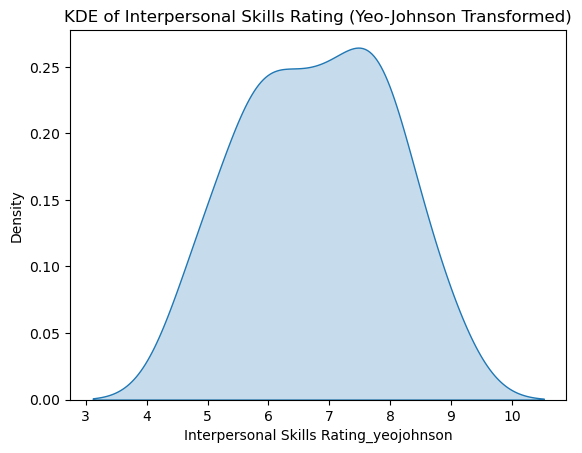

Shapiro-Wilk Test P-value: 0.014844538165733686


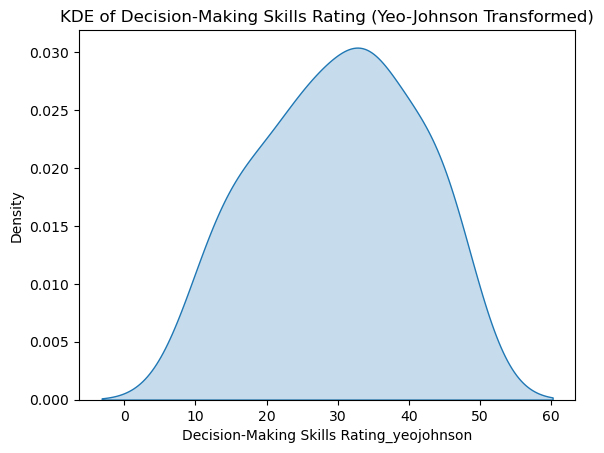

Shapiro-Wilk Test P-value: 0.006458355670975291


In [29]:
data = yeojohnson_transformation(data, 'Sales Revenue Generated')
data = yeojohnson_transformation(data, 'Task Completion Rates')
data = yeojohnson_transformation(data, 'Interpersonal Skills Rating')
data = yeojohnson_transformation(data, 'Decision-Making Skills Rating')

# 37.One Sample Test

In [112]:
from scipy import stats


hypothesis_mean = 68 

t_statistic, p_value = stats.ttest_1samp(data['Sales Revenue Generated'], hypothesis_mean)

# Significance level
alpha = 0.05


print("T-statistic:", t_statistic)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the null hypothesis. There is a significant difference between the average purchase amount and 68.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference between the average purchase amount and 68.")

T-statistic: 28.69414871437164
P-value: 2.2746688806072735e-23
Reject the null hypothesis. There is a significant difference between the average purchase amount and 68.


# 38.Independent Sample Test

In [114]:
from scipy import stats

# Sample data in churned
churned_customers = data[data['churned'] == 'Yes']['Sales Revenue Generated']
existing_customers = data[data['churned'] == 'No']['Sales Revenue Generated']

# two-sample t-test 
t_stat, p_value = stats.ttest_ind(churned_customers, existing_customers, alternative='greater')

# Output the t-statistic and p-value
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Decision based on significance level (α = 0.05)
alpha = 0.05
if p_value < alpha:
    print("✅ Reject the null hypothesis: Churned customers spent more than existing customers.")
else:
    print("❌ Fail to reject the null hypothesis: No significant difference in spending.")


T-statistic: 0.5816
P-value: 0.2827
❌ Fail to reject the null hypothesis: No significant difference in spending.


# 39.One Way Anova

In [116]:
import pandas as pd
from scipy import stats

# Sample DataFrame
data1 = pd.DataFrame({
    'City': ['New York', 'Chicago', 'New York', 'LA', 'Chicago', 'LA', 'New York'],
    'Purchase Frequency': [5, 3, 6, 4, 2, 5, 7]
})

# Get unique cities
cities = data1['City'].unique()

# Group purchase frequencies by city
purchase_frequencies_by_city = [data1[data1['City'] == city]['Purchase Frequency'] for city in cities]

# Perform One-Way ANOVA
f_stat, p_value = stats.f_oneway(*purchase_frequencies_by_city)

# Output the results
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Decision
alpha = 0.05
if p_value < alpha:
    print("✅ Reject the null hypothesis: There is a significant difference in purchase frequencies between cities.")
else:
    print("❌ Fail to reject the null hypothesis: No significant difference in purchase frequencies between cities.")


F-statistic: 9.8095
P-value: 0.0287
✅ Reject the null hypothesis: There is a significant difference in purchase frequencies between cities.


In [118]:
data1

,City,Purchase Frequency
0,New York,5
1,Chicago,3
2,New York,6
3,LA,4
4,Chicago,2
5,LA,5
6,New York,7


In [126]:
data.head(20)

,EmployeeID,gender,department,Days Present,Accuracy of Work,Meeting Project Deadlines,Task Completion Rates,Interpersonal Skills Rating,Decision-Making Skills Rating,Sales Revenue Generated,churned,Sales Revenue Generated (BoxCox)
0,1,Male,Sales,20,High,Yes,85,8,7,51638,No,34964.460549
1,2,Female,Marketing,22,Medium,Yes,90,7,6,97797,Yes,64563.891859
2,3,Male,Human Resources,25,High,No,80,9,8,95341,No,63005.976305
3,4,Male,Engineering,19,Low,Yes,75,6,5,91806,No,60760.811347
4,5,Female,Finance,23,Medium,Yes,85,7,7,64247,Yes,43127.065081
5,6,Male,Sales,21,High,Yes,95,8,8,89988,No,59604.827508
6,7,Female,Marketing,24,Low,No,70,5,4,70934,Yes,47429.345085
7,8,Male,Human Resources,18,Medium,Yes,80,6,6,96578,No,63790.839456
8,9,Male,Engineering,20,High,Yes,90,8,7,74219,No,49536.862265
9,10,Female,Finance,22,Medium,Yes,85,7,6,87009,Yes,57708.604120
